In [14]:
# main.py

import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from allocation.algorithms.nodal_clearing.nodal_fbmc import NodalDispatchModel

from allocation.algorithms.zonal_clearing.zonal_configuration import node_zone_mapper

from allocation.algorithms.zonal_clearing.zonal_fbmc import ZonalDispatchModel, BaseCaseGenerator, RedispatchModel, get_zone_maps

In [4]:
# --- 1. Setup Network and Zones ---
network = pypsa.Network("./data/raw_data/pypsa_eur_small/elec_s_40_ec_lv1.5_.nc")

In [5]:
# --- DEBUG CELL: INSPECT NETWORK DATA ---

print("--- Inspecting network.loads ---")
display(network.loads.head())

print("\n--- Inspecting network.loads_t.p_set ---")
# .describe() is perfect for seeing the min, max, and mean of the load
display(network.loads_t.p_set.describe())

# Check the total energy demand over the whole period
total_demand_mwh = network.loads_t.p_set.sum().sum()
print(f"\nTotal energy demand in the network object: {total_demand_mwh:,.2f} MWh")

if total_demand_mwh < 1:
    print("\n\n!!! CRITICAL WARNING: Total demand is near-zero. This is the likely cause of the infeasible results. !!!")
    print("Check how the PyPSA network object was created and if the load profile CSVs were loaded correctly.")

--- Inspecting network.loads ---


,bus,carrier,type,p_set,q_set,sign,active
Load,,,,,,,
DE0 0,DE0 0,,,0.0,0.0,-1.0,True
DE0 1,DE0 1,,,0.0,0.0,-1.0,True
DE0 10,DE0 10,,,0.0,0.0,-1.0,True
DE0 11,DE0 11,,,0.0,0.0,-1.0,True
DE0 12,DE0 12,,,0.0,0.0,-1.0,True



--- Inspecting network.loads_t.p_set ---


Load,DE0 0,DE0 1,DE0 10,DE0 11,DE0 12,DE0 13,DE0 14,DE0 15,DE0 16,DE0 17,...,DE0 36,DE0 37,DE0 38,DE0 39,DE0 4,DE0 5,DE0 6,DE0 7,DE0 8,DE0 9
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,...,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,1390.142221,1455.881410,1436.359588,1198.656401,2118.454630,1008.886518,555.885114,2080.943936,2806.261160,2352.848944,...,435.475305,1128.918397,2144.337837,1068.908188,2367.306327,3091.210555,2061.234111,2150.248949,1468.145038,1840.841117
std,179.669596,188.166089,185.642982,154.920920,273.800682,130.394020,71.845637,268.952594,362.696566,304.095087,...,56.283214,145.907598,277.145969,138.151550,305.963638,399.524986,266.405188,277.909954,189.751108,237.920390
min,1092.417006,1144.076905,1128.736051,941.941491,1664.747555,792.814413,436.831817,1635.270484,2205.247324,1848.941899,...,342.210043,887.139198,1685.087385,839.981309,1860.302961,2429.169424,1619.781891,1689.732520,1153.714046,1446.590220
25%,1216.245260,1273.760941,1256.681161,1048.712962,1853.450937,882.681949,486.347818,1820.632565,2455.217734,2058.524180,...,381.000424,987.698689,1876.096338,935.195333,2071.173047,2704.521975,1803.388300,1881.268012,1284.490476,1610.564911
50%,1465.585720,1534.892596,1514.311319,1263.707898,2233.423894,1063.639138,586.053192,2193.877482,2958.557922,2480.538869,...,459.108700,1190.185189,2260.711792,1126.918204,2495.780859,3258.971619,2173.097998,2266.943702,1547.821776,1940.744200
75%,1539.460774,1612.261168,1590.642460,1327.406997,2346.002986,1117.253469,615.594085,2304.463178,3107.688487,2605.574164,...,482.250765,1250.178264,2374.666372,1183.722212,2621.584450,3423.244988,2282.636273,2381.212411,1625.842062,2038.570332
max,1603.609025,1679.442961,1656.923417,1382.719116,2443.759287,1163.808639,641.245459,2400.488544,3237.183688,2714.146614,...,502.345817,1302.272317,2473.617056,1233.047088,2730.824037,3565.889208,2377.752127,2480.435864,1693.589762,2123.516130



Total energy demand in the network object: 1,507,714.29 MWh


In [6]:
print("--- Inspecting Generator Costs ---")
# See which generators have zero marginal cost
display(network.generators[['carrier', 'p_nom', 'marginal_cost']].sort_values('marginal_cost').head(10))

print("\n--- Inspecting a sample of time-varying generator availability (p_max_pu) ---")
# This should show values between 0.0 and 1.0 that change every hour for renewables
display(network.generators_t.p_max_pu.describe())

--- Inspecting Generator Costs ---


,carrier,p_nom,marginal_cost
Generator,,,
DE0 34 ror,ror,103.0637,0.009007
DE0 9 ror,ror,38.9060,0.009041
DE0 24 geothermal,geothermal,0.0000,0.009059
DE0 6 geothermal,geothermal,0.0000,0.009087
DE0 15 ror,ror,0.8230,0.009087
DE0 13 ror,ror,2.9310,0.009166
DE0 20 ror,ror,39.5580,0.009223
DE0 24 ror,ror,716.4291,0.009244
DE0 32 ror,ror,77.0500,0.009248



--- Inspecting a sample of time-varying generator availability (p_max_pu) ---


Generator,DE0 0 onwind,DE0 0 ror,DE0 0 solar,DE0 1 onwind,DE0 1 ror,DE0 1 solar,DE0 10 onwind,DE0 10 ror,DE0 10 solar,DE0 11 onwind,...,DE0 6 solar,DE0 7 onwind,DE0 7 ror,DE0 7 solar,DE0 8 onwind,DE0 8 ror,DE0 8 solar,DE0 9 onwind,DE0 9 ror,DE0 9 solar
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,...,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,0.002388,0.973122,0.037349,0.055814,0.973122,0.019361,0.031621,0.973122,0.059128,0.109668,...,0.116640,0.040658,0.973122,0.019616,0.073097,0.973122,0.019794,0.119739,0.973122,0.042726
std,0.008092,0.000743,0.052138,0.028795,0.000743,0.026283,0.040388,0.000743,0.083628,0.016733,...,0.172872,0.020962,0.000743,0.026268,0.028305,0.000743,0.025086,0.046432,0.000743,0.062523
min,0.000000,0.972004,0.000000,0.000000,0.972004,0.000000,0.000000,0.972004,0.000000,0.072709,...,0.000000,0.000000,0.972004,0.000000,0.040908,0.972004,0.000000,0.038817,0.972004,0.000000
25%,0.000000,0.972507,0.000000,0.036887,0.972507,0.000000,0.000000,0.972507,0.000000,0.098419,...,0.000000,0.029468,0.972507,0.000000,0.050902,0.972507,0.000000,0.078304,0.972507,0.000000
50%,0.000000,0.973060,0.000000,0.057280,0.973060,0.000000,0.000000,0.973060,0.000000,0.108224,...,0.000000,0.037837,0.973060,0.000000,0.067512,0.973060,0.000000,0.108621,0.973060,0.000000
75%,0.000000,0.973679,0.080055,0.075843,0.973679,0.045005,0.063422,0.973679,0.122770,0.124414,...,0.218106,0.058410,0.973679,0.042418,0.079679,0.973679,0.048874,0.167860,0.973679,0.077084
max,0.028878,0.974570,0.138720,0.125428,0.974570,0.063268,0.111737,0.974570,0.232439,0.144874,...,0.500152,0.076831,0.974570,0.066258,0.149132,0.974570,0.062578,0.186317,0.974570,0.192819


In [7]:
static_gens = network.generators.index
print("\n--- Inspecting static generators ---")
print(f"Number of static generators: {len(static_gens)}")
# inspecting generators with capacity >0
print(f"Number of static generators with capacity > 0: {len(static_gens[network.generators.p_nom > 0])}")


--- Inspecting static generators ---
Number of static generators: 446
Number of static generators with capacity > 0: 246


In [8]:
static_gens = network.generators.index
timeseries_gens = network.generators_t.p_max_pu.columns
missing_gens = static_gens.difference(timeseries_gens)
missing_gens

Index(['DE0 0 CCGT', 'DE0 0 OCGT', 'DE0 0 biomass', 'DE0 0 coal',
       'DE0 0 geothermal', 'DE0 0 lignite', 'DE0 0 nuclear', 'DE0 0 oil',
       'DE0 1 CCGT', 'DE0 1 OCGT',
       ...
       'DE0 8 nuclear', 'DE0 8 oil', 'DE0 9 CCGT', 'DE0 9 OCGT',
       'DE0 9 biomass', 'DE0 9 coal', 'DE0 9 geothermal', 'DE0 9 lignite',
       'DE0 9 nuclear', 'DE0 9 oil'],
      dtype='object', name='Generator', length=320)

In [9]:
# --- DATA CLEANING AND CONSISTENCY CHECK ---
# Run this cell once after loading your `network` object


# Identify generators that are in the static list but NOT in the time-series list

static_gens = network.generators.index
timeseries_gens = network.generators_t.p_max_pu.columns
missing_gens = static_gens.difference(timeseries_gens)

if not missing_gens.empty:
    print(f"Found {len(missing_gens)} generators missing from the time-series 'p_max_pu' DataFrame.")
    print("These are likely conventional generators. Adding them with 100% availability.")
    
    # For each missing generator, create a new time-series (a pandas Series)
    # with a constant value of 1.0 and assign it as a new column.
    for gen_name in missing_gens:
        # Create a Series with 1.0 for all snapshots, named after the generator
        availability_profile = pd.Series(1.0, index=network.snapshots, name=gen_name)
        network.generators_t.p_max_pu[gen_name] = availability_profile
        
    print("\nData cleaning complete. 'network.generators_t.p_max_pu' is now consistent.")
    
    # Re-check the difference. It should now be an empty Index.
    final_missing = network.generators.index.difference(network.generators_t.p_max_pu.columns)
    if final_missing.empty:
        print("Verification successful: All generators are now present in the time-series data.")
    else:
        print("!!! Verification FAILED. There is still a mismatch. !!!")
else:
    print("Data consistency check passed. No missing generators in 'p_max_pu'.")



Found 320 generators missing from the time-series 'p_max_pu' DataFrame.
These are likely conventional generators. Adding them with 100% availability.

Data cleaning complete. 'network.generators_t.p_max_pu' is now consistent.
Verification successful: All generators are now present in the time-series data.


C:\Users\paulw\AppData\Local\Temp\ipykernel_32680\1030282198.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  network.generators_t.p_max_pu[gen_name] = availability_profile
C:\Users\paulw\AppData\Local\Temp\ipykernel_32680\1030282198.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  network.generators_t.p_max_pu[gen_name] = availability_profile
C:\Users\paulw\AppData\Local\Temp\ipykernel_32680\1030282198.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

In [10]:
# Determine the network topology to identify connected components
network.determine_network_topology()

# The actual SubNetwork objects are stored in the `.subnetworks` accessor
# The `n.sub_networks` DataFrame just contains summary data.
sub_network_objects = network.sub_networks.obj

print(len(sub_network_objects))

# Check the size of each subnetwork (number of buses)
subnetwork_sizes = sub_network_objects.apply(lambda sn: len(sn.buses()))
print("Subnetwork sizes (number of buses):")
print(subnetwork_sizes.value_counts().sort_index())

print("\nCalculating PTDF matrix...")

if len(sub_network_objects) == 0:
    raise ValueError("No subnetworks found. The network might be empty or invalid.")
elif len(sub_network_objects) > 1:
    print(f"Warning: Found {len(sub_network_objects)} electrical subnetworks. "
          "PTDF will be calculated for the largest one.")
    # Find the largest subnetwork by length of its bus list
    main_sub_network = max(sub_network_objects, key=lambda sn: len(sn.buses()))
else:
    # If there's only one, just use it
    main_sub_network = sub_network_objects[0]
    
print(f"Selected the main subnetwork with {len(main_sub_network.buses())} buses.")
main_sub_network.calculate_PTDF()


ptdf_numpy = main_sub_network.PTDF

lines =  main_sub_network.lines_i()
buses = main_sub_network.buses_i()
print(f"PTDF matrix shape: {ptdf_numpy.shape} (lines: {len(lines)}, buses: {len(buses)})")

ptdf = pd.DataFrame(ptdf_numpy, index=lines, columns=buses)

ptdf_full = pd.DataFrame(0.0, index=network.lines.index, columns=network.buses.index)
ptdf_full.loc[lines, buses] = ptdf

nodal_ptdf = ptdf_full

81
Subnetwork sizes (number of buses):
obj
1     80
40     1
Name: count, dtype: int64

Calculating PTDF matrix...
Selected the main subnetwork with 40 buses.
PTDF matrix shape: (68, 40) (lines: 68, buses: 40)


In [11]:
def print_df_summary(df, name):
    """
    Prints a compact summary of a DataFrame's statistics.
    It does NOT print the whole DataFrame.
    """
    if df is None:
        print(f"--- Summary for {name}: DataFrame is None ---")
        return
    
    print(f"\n--- Fingerprint for: {name} (Shape: {df.shape}) ---")
    
    # .sum().sum() gives a single number representing the "total activity" in the DataFrame.
    # It's a very quick first-pass check.
    total_sum = df.sum().sum()
    print(f"Total Sum of all values: {total_sum:,.2f}")

    # .describe() creates a small summary table. We transpose it (.T) for readability.
    # This is the most powerful part. It gives you a detailed statistical fingerprint.
    summary_stats = df.describe().transpose()
    
    # To keep it even more compact, we can just show the summary for a few key columns/rows.
    # For example, let's just look at the 'mean' and 'std' for all columns.
    print("Statistical Summary (showing mean, std, min, max):")
    print(summary_stats[['mean', 'std', 'min', 'max']].to_string())
    print("-" * 60)

In [12]:
all_results = {}
# --- Instantiate model classes ---
zonal_model = ZonalDispatchModel()
redispatch_model = RedispatchModel()
ZONAL_CONFIG = 'zonal_DE4-refined'

scenarios_to_run = ['BC1', 'BC2', 'BC3.1', 'BC3.2', 'BC4']

# --- Main Computation Loop ---
for scenario in scenarios_to_run:
    print(f"\n{'='*25} RUNNING SCENARIO: {scenario} {'='*25}")

    # --- Step 1: Create the network for the scenario ---
    # This ensures demand modifications are handled correctly and consistently.
    base_network = network.copy() # Start with a fresh copy for each scenario
    if scenario == 'BC3.1':
        scenario_network = base_network
        scenario_network.loads_t.p_set *= 1.2
        print("Applied +20% uniform demand for BC3.1")
    elif scenario == 'BC3.2':
        scenario_network = base_network
        perturbation = 1 + (np.random.rand(*scenario_network.loads_t.p_set.shape) * 0.4 - 0.2)
        scenario_network.loads_t.p_set *= perturbation
        print("Applied +/- 20% random demand for BC3.2")
    else:
        scenario_network = base_network

    # --- Step 2: Generate the Base Case Flows ---
    # The BaseCaseGenerator gets the (potentially modified) network for the scenario
    base_case_generator = BaseCaseGenerator(scenario_network, nodal_ptdf, node_zone_mapper, ZONAL_CONFIG)
    p_bus_expected = base_case_generator.generate(base_case_type=scenario)
    if p_bus_expected is None:
        print(f"FAILED to generate base case for {scenario}. SKIPPING. "); continue

    # --- Step 3: Run Zonal Dispatch ---
    # The Zonal Model also gets the same (potentially modified) network
    zonal_results = zonal_model.solve(
            network=scenario_network, nodal_ptdf=nodal_ptdf, p_bus_expected=p_bus_expected,
            node_zone_mapper=node_zone_mapper, zonal_configuration=ZONAL_CONFIG, verbose=False
        )
    if not zonal_results:
        print(f"--> Scenario '{scenario}' FAILED during zonal dispatch."); continue
    all_results[scenario] = {'zonal_market': zonal_results}

    # --- Step 4: Run Redispatch for R1 and R2 ---
    for redispatch_method in ['R1', 'R2']:
        print(f"  -> Running Redispatch Method: {redispatch_method}")
        # The Redispatch Model also gets the same (potentially modified) network
        redispatch_results = redispatch_model.solve(
            network=scenario_network, ptdf=nodal_ptdf, zonal_results=zonal_results,
            node_zone_mapper=node_zone_mapper, zonal_configuration=ZONAL_CONFIG,
            method=redispatch_method, verbose=False
        )
        all_results[scenario][f'redispatch_{redispatch_method}'] = redispatch_results


========================= RUNNING SCENARIO: BC1 =========================
Set parameter Username
Set parameter LicenseID to value 2655639
Academic license - for non-commercial use only - expires 2026-04-22
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
  -> Running Redispatch Method: R1
Set parameter LogToConsole to value 0
  -> Running Redispatch Method: R2
Set parameter LogToConsole to value 0

========================= RUNNING SCENARIO: BC2 =========================
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
  -> Running Redispatch Method: R1
Set parameter LogToConsole to value 0
  -> Running Redispatch Method: R2
Set parameter LogToConsole to value 0

========================= RUNNING SCENARIO: BC3.1 =========================
Applied +20% uniform demand for BC3.1
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
  -> Running Redispatch Method: R1
Set parameter LogToConsole to value 0
  -> Runni


           RESULTS ANALYSIS & COMPARISON
--- Calculating Nodal Baseline Cost (on original network) ---
Set parameter LogToConsole to value 0
Optimal MILP solution found. Total Cost: 18073552.70
Nodal (Optimal) Total System Cost: 18,073,552.70

--------------------------------------------------------------------------------
      COST SUMMARY TABLE
--------------------------------------------------------------------------------


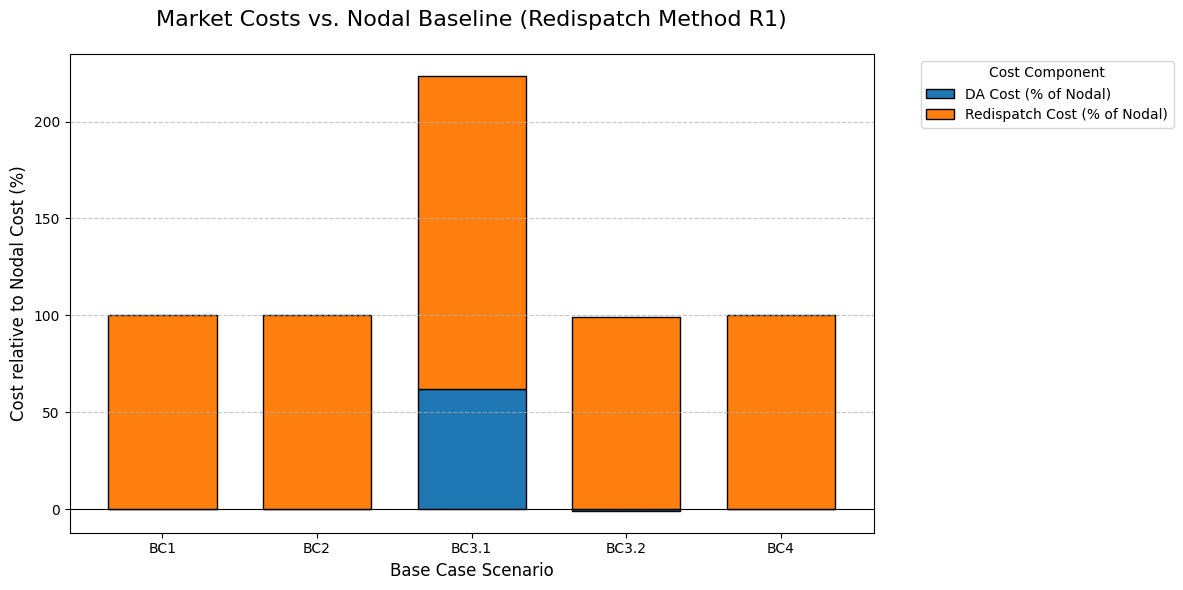

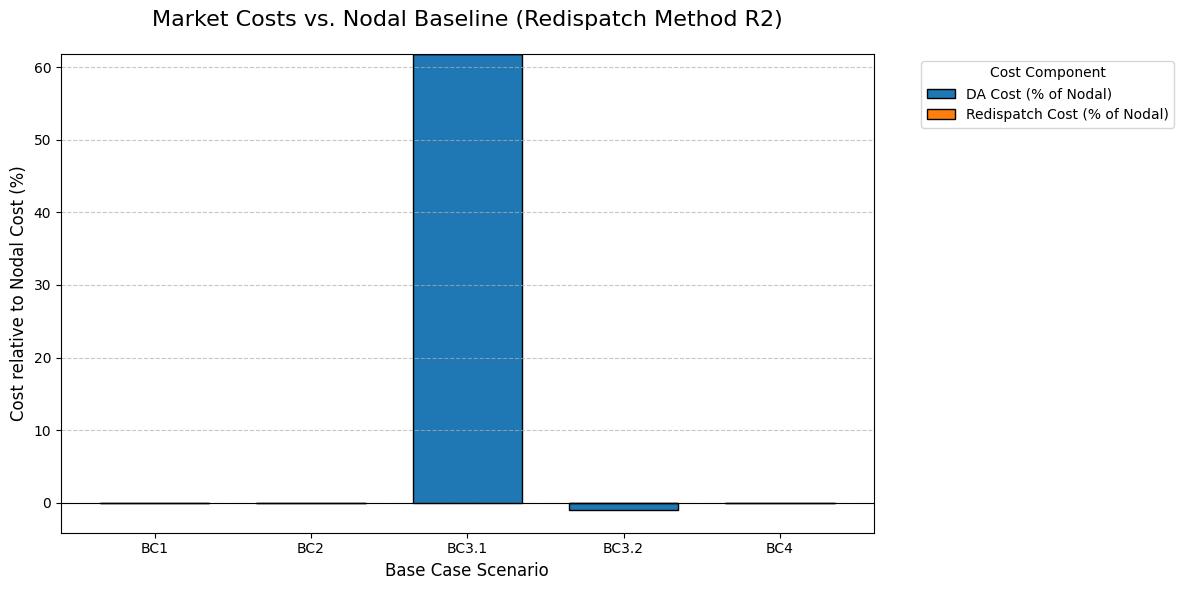

In [15]:
print("\n" + "="*50)
print("           RESULTS ANALYSIS & COMPARISON")
print("="*50)

print("--- Calculating Nodal Baseline Cost (on original network) ---")
nodal_model = NodalDispatchModel()
# Use the original, unmodified network for the baseline
nodal_results = nodal_model.solve(network, nodal_ptdf, verbose=False)

if not nodal_results:
    print("!!! CRITICAL: Nodal solution failed. Cannot calculate relative costs. !!!")
    nodal_total_cost = 0
else:
    nodal_total_cost = nodal_results['objective_value']
    print(f"Nodal (Optimal) Total System Cost: {nodal_total_cost:,.2f}")

# --- Process the results from all scenarios ---
summary_data = []
scenarios_run = list(all_results.keys()) 

for scenario in scenarios_run:
    for redispatch_method in ['R1', 'R2']:
        key = f'redispatch_{redispatch_method}'
        if (scenario in all_results and key in all_results[scenario] and all_results[scenario][key] and all_results[scenario][key].get('status') == 'Optimal'):
            zonal_res = all_results[scenario]['zonal_market']
            redispatch_res = all_results[scenario][key]
            
            da_cost = zonal_res['objective_value']
            redispatch_cost = redispatch_res['redispatch_cost']
            final_cost = redispatch_res['final_operating_cost']
            
            # For R1, the 'total cost' is the objective value. For R2, it's the sum.
            total_cost = final_cost if redispatch_method == 'R1' else da_cost + redispatch_cost
            
            if nodal_total_cost > 0:
                total_cost_vs_nodal = (total_cost - nodal_total_cost) / nodal_total_cost * 100
                da_cost_vs_nodal = (da_cost - nodal_total_cost) / nodal_total_cost * 100
                redispatch_cost_vs_nodal = redispatch_cost / nodal_total_cost * 100
            else:
                total_cost_vs_nodal, da_cost_vs_nodal, redispatch_cost_vs_nodal = float('nan'), float('nan'), float('nan')

            summary_data.append({
                'Scenario': scenario, 'Redispatch Method': redispatch_method, 'DA Cost': da_cost,
                'Redispatch Cost': redispatch_cost, 'Total Cost': total_cost,
                '% Total vs Nodal': total_cost_vs_nodal, '% DA vs Nodal': da_cost_vs_nodal,
                '% Redispatch vs Nodal': redispatch_cost_vs_nodal,
            })
        else:
            print(f"Skipping {scenario} - {redispatch_method}: No valid results available")

# --- Create a clean DataFrame and plot ---
if summary_data:
    results_df = pd.DataFrame(summary_data).set_index(['Scenario', 'Redispatch Method'])
    print("\n" + "-"*80); print("      COST SUMMARY TABLE"); print("-"*80)
    display(results_df.style.format({
        'DA Cost': '{:,.2f}', 'Redispatch Cost': '{:,.2f}', 'Total Cost': '{:,.2f}',
        '% Total vs Nodal': '{:+.2f}%', '% DA vs Nodal': '{:+.2f}%', '% Redispatch vs Nodal': '{:+.2f}%',
    }))

    def plot_cost_comparison(df, redispatch_method, title):
        try:
            plot_df = df.loc[pd.IndexSlice[:, redispatch_method], ['% DA vs Nodal', '% Redispatch vs Nodal']].copy()
            plot_df.reset_index(level='Redispatch Method', drop=True, inplace=True)
            plot_df.rename(columns={'% DA vs Nodal': 'DA Cost (% of Nodal)', '% Redispatch vs Nodal': 'Redispatch Cost (% of Nodal)'}, inplace=True)
            ax = plot_df.plot(kind='bar', stacked=True, figsize=(12, 6), width=0.7, edgecolor='black')
            ax.set_title(title, fontsize=16, pad=20); ax.set_ylabel('Cost relative to Nodal Cost (%)', fontsize=12)
            ax.set_xlabel('Base Case Scenario', fontsize=12); ax.tick_params(axis='x', rotation=0)
            ax.axhline(0, color='black', linewidth=0.8); ax.legend(title='Cost Component', bbox_to_anchor=(1.05, 1), loc='upper left')
            ax.grid(axis='y', linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()
        except KeyError: print(f"No data to plot for method {redispatch_method}")

    if 'R1' in results_df.index.get_level_values('Redispatch Method'): plot_cost_comparison(results_df, 'R1', 'Market Costs vs. Nodal Baseline (Redispatch Method R1)')
    if 'R2' in results_df.index.get_level_values('Redispatch Method'): plot_cost_comparison(results_df, 'R2', 'Market Costs vs. Nodal Baseline (Redispatch Method R2)')
else:
    print("\nNo successful scenarios to analyze. Please check the logs for errors.")


           RESULTS ANALYSIS & COMPARISON
--- Calculating Nodal Baseline Cost (on original network) ---
Set parameter LogToConsole to value 0
Optimal MILP solution found. Total Cost: 18073552.70
Nodal (Optimal) Total System Cost: 18,073,552.70

--------------------------------------------------------------------------------
      COST SUMMARY TABLE (ALL VALUES IN CURRENCY, UNLESS SPECIFIED AS %)
--------------------------------------------------------------------------------


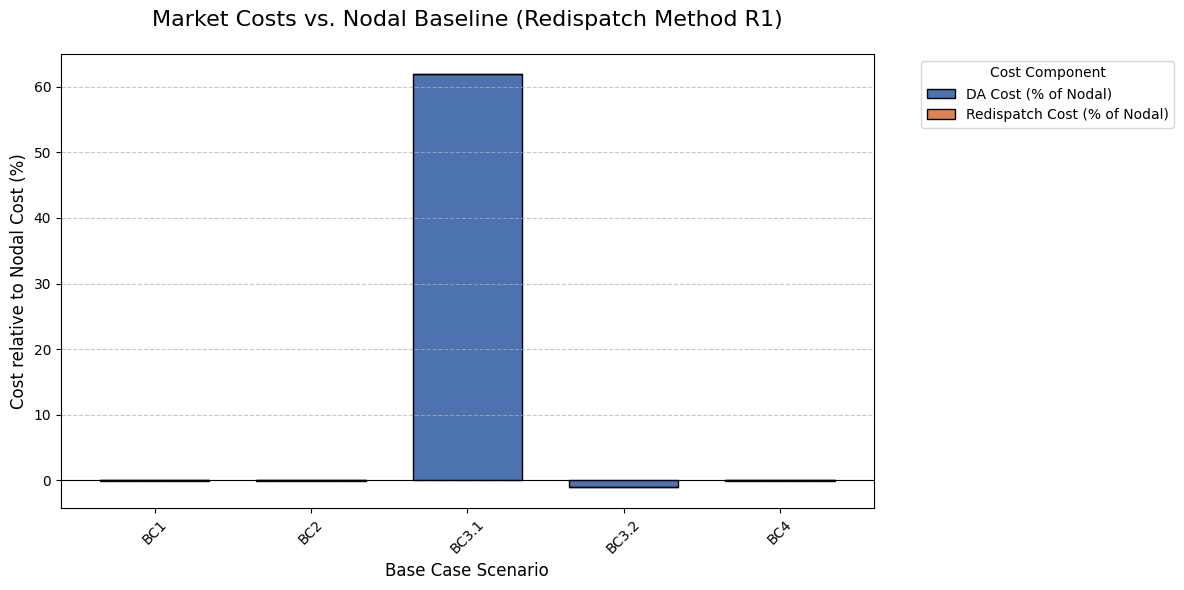

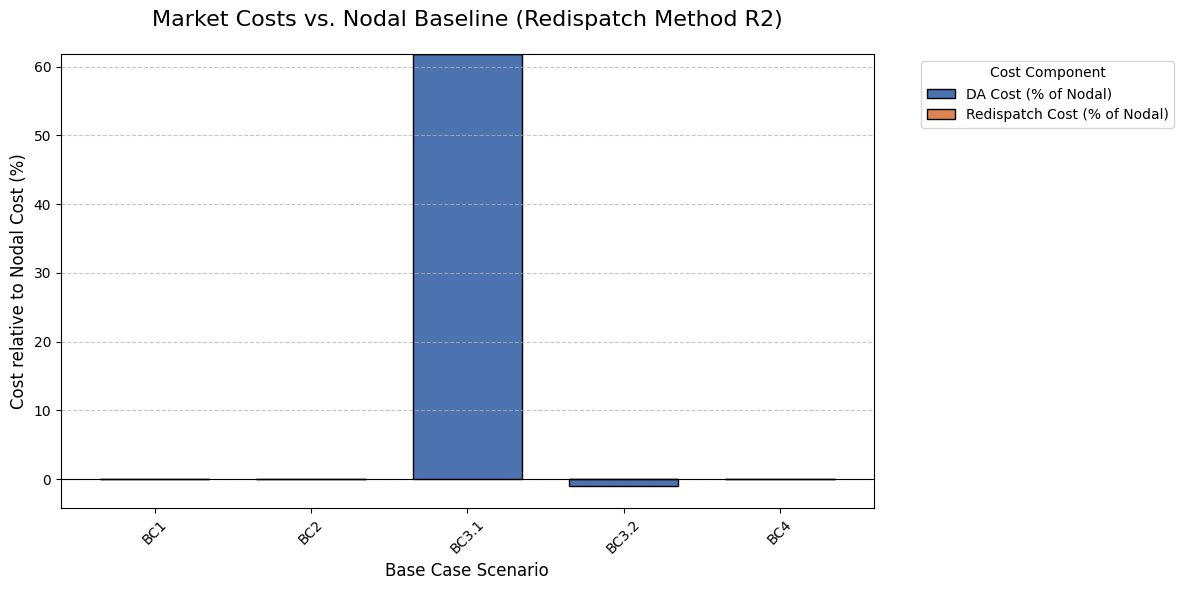

In [16]:
print("\n" + "="*50)
print("           RESULTS ANALYSIS & COMPARISON")
print("="*50)

# --- First, we need the Nodal baseline cost for the ORIGINAL network ---
print("--- Calculating Nodal Baseline Cost (on original network) ---")
nodal_model = NodalDispatchModel()
# Use the original, unmodified network for the baseline
nodal_results = nodal_model.solve(network, nodal_ptdf, verbose=False)

if not nodal_results:
    print("!!! CRITICAL: Nodal solution failed. Cannot calculate relative costs. !!!")
    nodal_total_cost = 0
else:
    nodal_total_cost = nodal_results['objective_value']
    print(f"Nodal (Optimal) Total System Cost: {nodal_total_cost:,.2f}")

# --- Process the results from all scenarios ---
summary_data = []
scenarios_run = list(all_results.keys()) 

for scenario in scenarios_run:
    for redispatch_method in ['R1', 'R2']:
        key = f'redispatch_{redispatch_method}'
        
        # Check if the results for this combination exist and were successful
        if (scenario in all_results and 
            key in all_results[scenario] and 
            all_results[scenario][key] and 
            all_results[scenario][key].get('status') == 'Optimal'):
            
            zonal_res = all_results[scenario]['zonal_market']
            redispatch_res = all_results[scenario][key]

            # --- Extract the core costs ---
            # 1. Day-Ahead Cost (from the zonal market solution)
            da_cost = zonal_res['objective_value']
            
            # 2. Final Physical Cost
            final_cost = redispatch_res['final_operating_cost']

            # *** CRITICAL CHANGE IS HERE ***
            # 3. Redispatch Cost Calculation
            if redispatch_method == 'R1':
                # For R1, the redispatch cost is the difference between the final
                # physical cost and the day-ahead market cost.
                redispatch_cost = final_cost - da_cost
            else: # For R2
                # For R2, the redispatch cost is the direct TSO payout.
                redispatch_cost = redispatch_res['redispatch_cost']
            
            # 4. Total Cost is always the final physical cost of the system
            total_cost = final_cost
            
            # --- Calculate metrics relative to the Nodal baseline ---
            if nodal_total_cost > 0:
                total_cost_vs_nodal = (total_cost - nodal_total_cost) / nodal_total_cost * 100
                da_cost_vs_nodal = (da_cost - nodal_total_cost) / nodal_total_cost * 100
                redispatch_cost_vs_nodal = redispatch_cost / nodal_total_cost * 100
            else:
                total_cost_vs_nodal, da_cost_vs_nodal, redispatch_cost_vs_nodal = float('nan'), float('nan'), float('nan')

            summary_data.append({
                'Scenario': scenario,
                'Redispatch Method': redispatch_method,
                'DA Cost': da_cost,
                'Redispatch Cost': redispatch_cost,
                'Total Cost': total_cost,
                '% Total vs Nodal': total_cost_vs_nodal,
                '% DA vs Nodal': da_cost_vs_nodal,
                '% Redispatch vs Nodal': redispatch_cost_vs_nodal,
            })
        else:
            print(f"Skipping {scenario} - {redispatch_method}: No valid results available")

# --- Create a clean DataFrame for comparison ---
if summary_data:
    results_df = pd.DataFrame(summary_data)
    results_df.set_index(['Scenario', 'Redispatch Method'], inplace=True)

    # Display the final summary table
    print("\n" + "-"*80)
    print("      COST SUMMARY TABLE (ALL VALUES IN CURRENCY, UNLESS SPECIFIED AS %)")
    print("-"*80)
    display(results_df.style.format({
        'DA Cost': '{:,.2f}',
        'Redispatch Cost': '{:,.2f}',
        'Total Cost': '{:,.2f}',
        '% Total vs Nodal': '{:+.2f}%',
        '% DA vs Nodal': '{:+.2f}%',
        '% Redispatch vs Nodal': '{:+.2f}%',
    }))

    # --- Generate Bar Charts (this code does not need to be changed) ---
    def plot_cost_comparison(df, redispatch_method, title):
        try:
            plot_df = df.loc[pd.IndexSlice[:, redispatch_method], ['% DA vs Nodal', '% Redispatch vs Nodal']].copy()
        except KeyError:
            print(f"No data available for redispatch method {redispatch_method}")
            return
        
        if plot_df.empty:
            print(f"No data to plot for redispatch method {redispatch_method}")
            return
        
        plot_df.reset_index(level='Redispatch Method', drop=True, inplace=True)
        plot_df.rename(columns={'% DA vs Nodal': 'DA Cost (% of Nodal)', '% Redispatch vs Nodal': 'Redispatch Cost (% of Nodal)'}, inplace=True)
        ax = plot_df.plot(kind='bar', stacked=True, figsize=(12, 6), width=0.7, edgecolor='black', color=['#4C72B0', '#DD8452'])
        ax.set_title(title, fontsize=16, pad=20); ax.set_ylabel('Cost relative to Nodal Cost (%)', fontsize=12)
        ax.set_xlabel('Base Case Scenario', fontsize=12); ax.tick_params(axis='x', rotation=45)
        ax.axhline(0, color='black', linewidth=0.8); ax.legend(title='Cost Component', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(axis='y', linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()

    if 'R1' in results_df.index.get_level_values('Redispatch Method'): plot_cost_comparison(results_df, 'R1', 'Market Costs vs. Nodal Baseline (Redispatch Method R1)')
    if 'R2' in results_df.index.get_level_values('Redispatch Method'): plot_cost_comparison(results_df, 'R2', 'Market Costs vs. Nodal Baseline (Redispatch Method R2)')

else:
    print("\nNo successful scenarios to analyze. Please check the logs for errors.")